In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([-1 , -1 , -1 , -1])

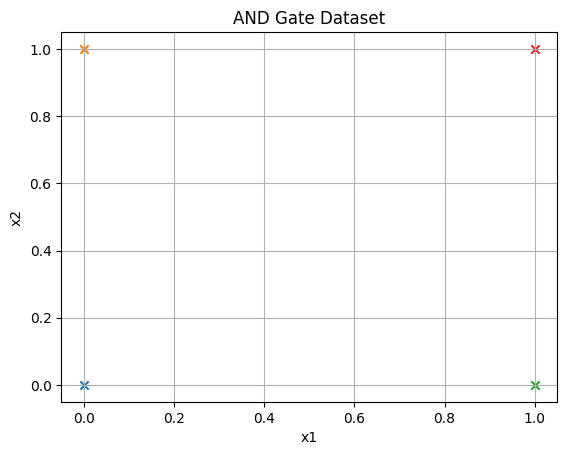

In [ ]:
for i in range(len(X)):
  if y[i] == 1 :
    plt.scatter(X[i][0], X[i][1], marker='o')
  else:
    plt.scatter(X[i][0], X[i][1], marker='x')

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("AND Gate Dataset")
plt.grid()
plt.show()

In [ ]:
X.shape[1]

2

In [ ]:
class Perceptron():
  def __init__(self , learning_rate = 0.01 , epochs = 10):
    self.learning_rate = learning_rate
    self.epochs = epochs

  def fit(self , X , y):
    n_feature = X.shape[1]
    self.w = np.zeros(n_feature)
    self.b = 0
    for epoch in range(self.epochs):
      error = 0
      for i in range(len(X)):
        linear_output = np.dot(X[i] , self.w) + self.b
        y_pred = 1 if linear_output >= 0 else -1
        if y_pred != y[i]:
          self.w += self.learning_rate * y[i] * X[i]
          self.b += self.learning_rate * y[i]
          error += 1
        print(f"Epoch : {epoch} , Error : {error}")

  def predict(self , X):
    linear_output = np.dot(X , self.w) + self.b
    return np.where(linear_output >= 0 , 1 , -1)

In [ ]:
# The predict function has been moved into the Perceptron class in cell LTuUcJXnBjLp. This cell is now empty or can be removed.

In [ ]:
model = Perceptron(learning_rate=1.0, epochs=10)

model.fit(X, y)

Epoch : 0 , Error : 1
Epoch : 0 , Error : 1
Epoch : 0 , Error : 1
Epoch : 0 , Error : 1
Epoch : 1 , Error : 0
Epoch : 1 , Error : 0
Epoch : 1 , Error : 0
Epoch : 1 , Error : 0
Epoch : 2 , Error : 0
Epoch : 2 , Error : 0
Epoch : 2 , Error : 0
Epoch : 2 , Error : 0
Epoch : 3 , Error : 0
Epoch : 3 , Error : 0
Epoch : 3 , Error : 0
Epoch : 3 , Error : 0
Epoch : 4 , Error : 0
Epoch : 4 , Error : 0
Epoch : 4 , Error : 0
Epoch : 4 , Error : 0
Epoch : 5 , Error : 0
Epoch : 5 , Error : 0
Epoch : 5 , Error : 0
Epoch : 5 , Error : 0
Epoch : 6 , Error : 0
Epoch : 6 , Error : 0
Epoch : 6 , Error : 0
Epoch : 6 , Error : 0
Epoch : 7 , Error : 0
Epoch : 7 , Error : 0
Epoch : 7 , Error : 0
Epoch : 7 , Error : 0
Epoch : 8 , Error : 0
Epoch : 8 , Error : 0
Epoch : 8 , Error : 0
Epoch : 8 , Error : 0
Epoch : 9 , Error : 0
Epoch : 9 , Error : 0
Epoch : 9 , Error : 0
Epoch : 9 , Error : 0


In [ ]:
predictions = model.predict(X)

print("Predictions:", predictions)
print("Ground Truth:", y)

Predictions: [-1 -1 -1 -1]
Ground Truth: [-1 -1 -1 -1]


In [ ]:
accuracy = np.mean(predictions == y)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
def plot_decision_boundary(X, y, model):

    x_min, x_max = -1, 2
    y_min, y_max = -1, 2

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)

    for i in range(len(X)):
        if y[i] == 1:
            plt.scatter(X[i][0], X[i][1], marker='o')
        else:
            plt.scatter(X[i][0], X[i][1], marker='x')

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Perceptron Decision Boundary")
    plt.show()

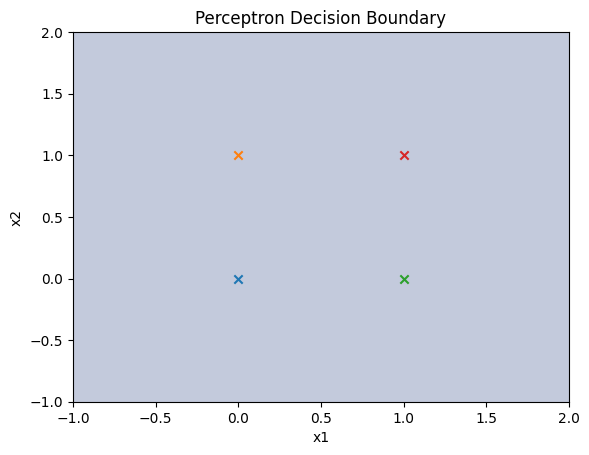

In [ ]:
plot_decision_boundary(X, y, model)

Shape of X_new: (100, 2)
Shape of y_new: (100,)


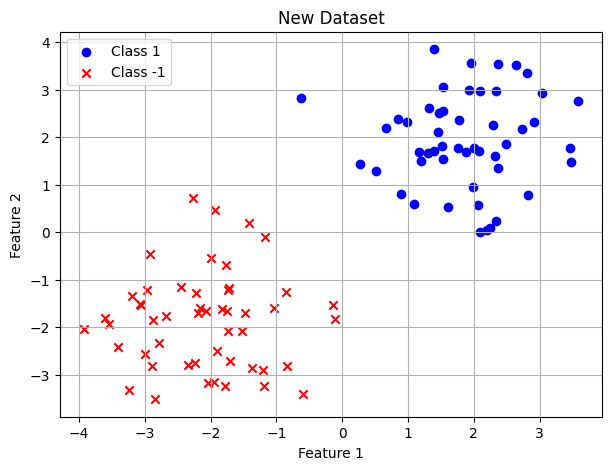

In [ ]:
# 1. Define the new dataset as provided by the user
np.random.seed(42)

class1 = np.random.randn(50,2) + [2,2]
class2 = np.random.randn(50,2) + [-2,-2]

X_new = np.vstack((class1, class2))
y_new = np.array([1]*50 + [-1]*50)

print("Shape of X_new:", X_new.shape)
print("Shape of y_new:", y_new.shape)

# Visualize the new dataset
plt.figure(figsize=(7, 5))
plt.scatter(X_new[y_new == 1, 0], X_new[y_new == 1, 1], color='blue', marker='o', label='Class 1')
plt.scatter(X_new[y_new == -1, 0], X_new[y_new == -1, 1], color='red', marker='x', label='Class -1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('New Dataset')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
class SimplePerceptron:
    def __init__(self, learning_rate=0.1, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def fit(self, X, y, plot_during_training=False, plot_interval=1, X_plot=None, y_plot=None):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):
            errors = 0
            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                # Activation function: step function (output -1 or 1)
                y_predicted = 1 if linear_output >= 0 else -1

                if y_predicted != y[i]:
                    # Update weights and bias
                    self.weights += self.learning_rate * y[i] * X[i]
                    self.bias += self.learning_rate * y[i]
                    errors += 1

            print(f"Epoch {epoch+1}/{self.epochs}, Errors: {errors}, Weights: {self.weights}, Bias: {self.bias}")

            if plot_during_training and (epoch + 1) % plot_interval == 0:
                if X_plot is not None and y_plot is not None:
                    plot_perceptron_decision_boundary(X_plot, y_plot, self, title=f"Epoch {epoch+1} Decision Boundary")
                else:
                    plot_perceptron_decision_boundary(X, y, self, title=f"Epoch {epoch+1} Decision Boundary")

            if errors == 0:
                print(f"Training converged at epoch {epoch+1}")
                break
        print(f"Final weights: {self.weights}, Final bias: {self.bias}")

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, -1)

In [ ]:
def plot_perceptron_decision_boundary(X, y, model, title="Perceptron Decision Boundary"):
    plt.figure(figsize=(7, 5))
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    # Plot data points
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='o', label='Class 1')
    plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', marker='x', label='Class -1')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
perceptron_model_new = SimplePerceptron(learning_rate=0.01, epochs=1000) # Increased epochs for potentially harder dataset
perceptron_model_new.fit(X_new, y_new)

Epoch 1/1000, Errors: 1, Weights: [0.03415371 0.02420645], Bias: -0.01
Epoch 2/1000, Errors: 0, Weights: [0.03415371 0.02420645], Bias: -0.01
Training converged at epoch 2
Final weights: [0.03415371 0.02420645], Final bias: -0.01


In [ ]:
predictions_new = perceptron_model_new.predict(X_new)
accuracy_new = np.mean(predictions_new == y_new)

print("Ground Truth (y_new):\n", y_new)
print("Predictions (predictions_new):\n", predictions_new)
print(f"Accuracy on new dataset: {accuracy_new * 100:.2f}%")

Ground Truth (y_new):
 [ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1]
Predictions (predictions_new):
 [ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1]
Accuracy on new dataset: 100.00%


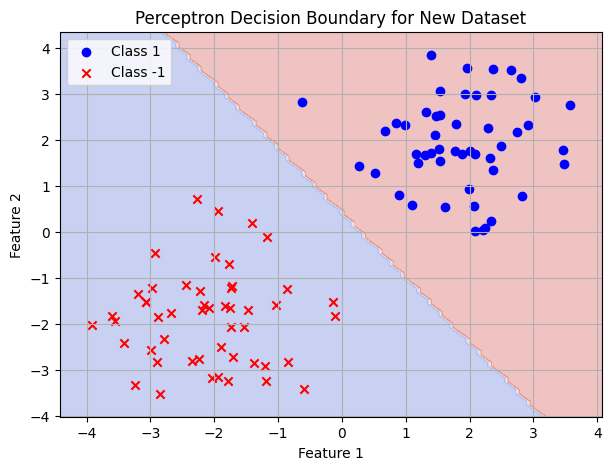

In [53]:
plot_perceptron_decision_boundary(X_new, y_new, perceptron_model_new, title="Perceptron Decision Boundary for New Dataset")

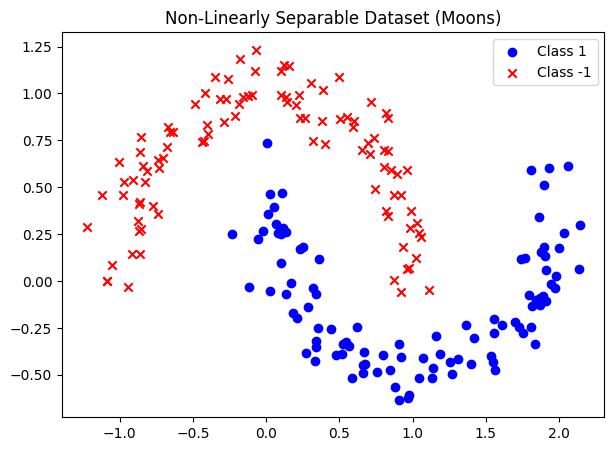

In [ ]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)
y_moons = np.where(y_moons == 0, -1, 1)

plt.figure(figsize=(7, 5))
plt.scatter(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1], color='blue', marker='o', label='Class 1')
plt.scatter(X_moons[y_moons == -1, 0], X_moons[y_moons == -1, 1], color='red', marker='x', label='Class -1')
plt.title('Non-Linearly Separable Dataset (Moons)')
plt.legend()
plt.show()

In [ ]:
print(X_moons.shape)
print(y_moons.shape)

(200, 2)
(200,)


In [ ]:
X_moons

array([[-1.04942573e+00,  8.44426315e-02],
       [ 9.22817545e-01,  4.57488507e-01],
       [ 6.56786593e-01,  6.99596694e-01],
       [ 1.18894020e+00, -3.86528073e-01],
       [ 2.89264549e-01, -1.37744892e-01],
       [ 2.51685082e-01,  1.81006054e-01],
       [-6.68120991e-01,  8.22265447e-01],
       [ 1.55626644e+00, -2.03445580e-01],
       [ 1.87213538e+00, -1.25335230e-01],
       [ 1.43229273e-01,  9.53267512e-01],
       [-4.35091327e-01,  7.43738050e-01],
       [ 1.91161702e+00, -1.05146485e-01],
       [ 1.53432590e+00, -3.97547101e-01],
       [-8.24879535e-01,  5.29607749e-01],
       [ 1.88043395e+00,  1.54681644e-01],
       [ 1.87043050e+00, -9.01427936e-02],
       [-6.84180156e-02,  1.23271872e+00],
       [ 1.04680086e+00, -5.17441448e-01],
       [-1.00198756e+00,  6.32750117e-01],
       [-4.23980382e-01,  7.45855239e-01],
       [ 3.38030046e-01, -6.83719318e-02],
       [ 8.96478204e-01,  5.70936879e-01],
       [ 9.69901385e-01, -6.20552828e-01],
       [-8.

In [ ]:
y_moons

array([-1, -1, -1,  1,  1,  1, -1,  1,  1, -1, -1,  1,  1, -1,  1,  1, -1,
        1, -1, -1,  1, -1,  1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1, -1,
        1,  1,  1,  1,  1, -1, -1,  1, -1, -1,  1,  1, -1, -1,  1, -1,  1,
        1, -1,  1,  1, -1,  1, -1,  1, -1,  1, -1, -1, -1, -1,  1, -1,  1,
       -1,  1, -1,  1,  1, -1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1,  1,
       -1,  1, -1,  1, -1, -1,  1,  1, -1, -1,  1,  1, -1, -1,  1, -1, -1,
        1,  1,  1,  1, -1, -1,  1,  1,  1, -1,  1,  1, -1,  1, -1, -1,  1,
       -1, -1,  1,  1,  1, -1, -1,  1,  1, -1, -1,  1, -1, -1,  1, -1,  1,
       -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1,  1, -1, -1,  1,  1, -1,
       -1, -1, -1,  1,  1, -1, -1,  1,  1,  1,  1, -1, -1,  1, -1,  1, -1,
       -1, -1, -1, -1,  1,  1,  1, -1,  1,  1, -1, -1,  1,  1,  1,  1, -1,
        1, -1, -1,  1,  1, -1,  1, -1,  1, -1, -1,  1,  1])

### Train the Perceptron on Moons data

Since this data is not linearly separable, the Perceptron will not converge (errors will not reach 0). We will limit the epochs and visualize the result.

Epoch 1/50, Errors: 42, Weights: [ 0.01750915 -0.01801264], Bias: 0.02
Epoch 2/50, Errors: 41, Weights: [ 0.00848927 -0.02109674], Bias: 0.01
Epoch 3/50, Errors: 45, Weights: [ 0.01333741 -0.02715184], Bias: 0.02
Epoch 4/50, Errors: 37, Weights: [ 0.01059176 -0.02945343], Bias: 0.01
Epoch 5/50, Errors: 36, Weights: [ 0.0083099  -0.02369431], Bias: 0.01
Epoch 6/50, Errors: 36, Weights: [ 0.00249675 -0.02968093], Bias: 0.01
Epoch 7/50, Errors: 38, Weights: [ 0.0091851 -0.0257434], Bias: 0.01
Epoch 8/50, Errors: 40, Weights: [ 0.00920632 -0.02616885], Bias: 0.01
Epoch 9/50, Errors: 40, Weights: [ 0.00922753 -0.0265943 ], Bias: 0.01
Epoch 10/50, Errors: 40, Weights: [ 0.00924875 -0.02701976], Bias: 0.01


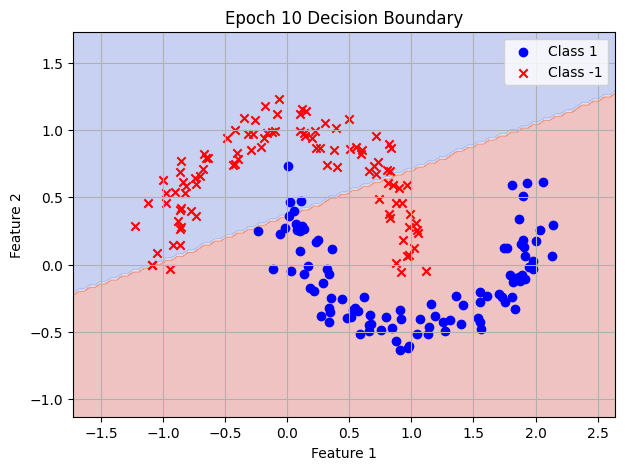

Epoch 11/50, Errors: 40, Weights: [ 0.00926997 -0.02744521], Bias: 0.01
Epoch 12/50, Errors: 40, Weights: [ 0.00929118 -0.02787066], Bias: 0.01
Epoch 13/50, Errors: 36, Weights: [ 0.0095414  -0.02898924], Bias: 0.01
Epoch 14/50, Errors: 36, Weights: [ 0.00772426 -0.02186564], Bias: 0.01
Epoch 15/50, Errors: 36, Weights: [ 0.00315214 -0.03114692], Bias: 0.01
Epoch 16/50, Errors: 32, Weights: [ 0.0123238  -0.02820806], Bias: 0.01
Epoch 17/50, Errors: 36, Weights: [-0.00062103 -0.01767433], Bias: 0.01
Epoch 18/50, Errors: 40, Weights: [ 0.00990153 -0.02544847], Bias: 0.01
Epoch 19/50, Errors: 40, Weights: [ 0.00068064 -0.01823324], Bias: 0.01
Epoch 20/50, Errors: 44, Weights: [ 0.01312193 -0.02793445], Bias: 0.01


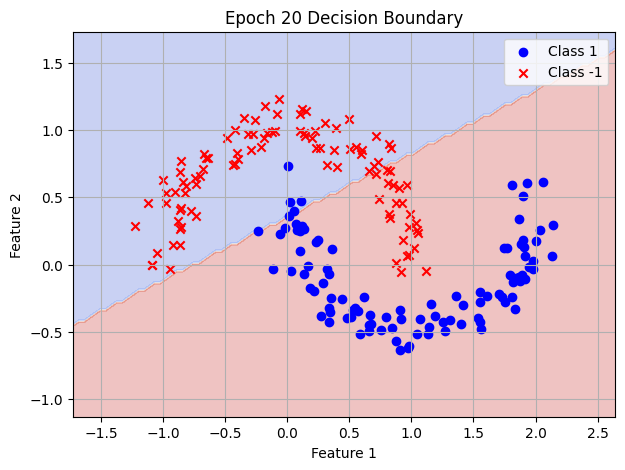

Epoch 21/50, Errors: 39, Weights: [ 0.01471191 -0.02717628], Bias: 0.02
Epoch 22/50, Errors: 37, Weights: [ 0.00811544 -0.02389688], Bias: 0.01
Epoch 23/50, Errors: 36, Weights: [ 0.00230229 -0.0298835 ], Bias: 0.01
Epoch 24/50, Errors: 38, Weights: [ 0.0006199  -0.03166982], Bias: 0.01
Epoch 25/50, Errors: 36, Weights: [ 0.00187629 -0.02989366], Bias: 0.01
Epoch 26/50, Errors: 38, Weights: [ 0.00019391 -0.03167997], Bias: 0.01
Epoch 27/50, Errors: 36, Weights: [ 0.0014503  -0.02990382], Bias: 0.01
Epoch 28/50, Errors: 34, Weights: [-0.00035597 -0.02724323], Bias: 0.01
Epoch 29/50, Errors: 36, Weights: [ 0.00600376 -0.02452445], Bias: 0.01
Epoch 30/50, Errors: 40, Weights: [ 0.0115974 -0.0260033], Bias: 0.01


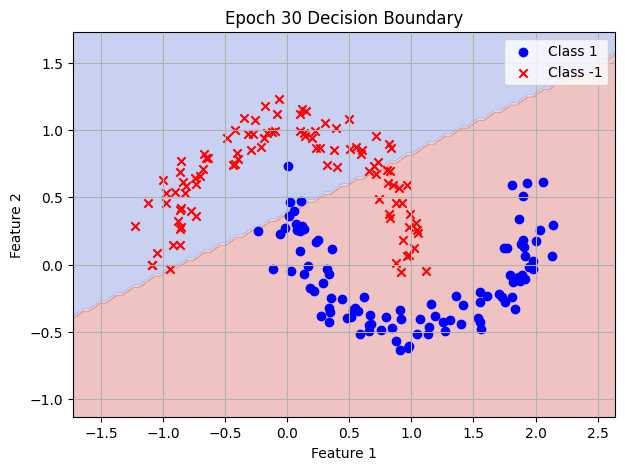

Epoch 31/50, Errors: 42, Weights: [ 0.01007416 -0.03008462], Bias: 0.01
Epoch 32/50, Errors: 36, Weights: [ 0.00825702 -0.02296102], Bias: 0.01
Epoch 33/50, Errors: 38, Weights: [ 0.00109329 -0.01442828], Bias: 0.01
Epoch 34/50, Errors: 46, Weights: [ 0.01045369 -0.02892248], Bias: 0.01
Epoch 35/50, Errors: 36, Weights: [ 0.00817184 -0.02316335], Bias: 0.01
Epoch 36/50, Errors: 38, Weights: [ 0.0133138  -0.03386512], Bias: 0.01
Epoch 37/50, Errors: 36, Weights: [ 0.01107567 -0.03068101], Bias: 0.01
Epoch 38/50, Errors: 36, Weights: [-0.00087892 -0.03270785], Bias: 0.01
Epoch 39/50, Errors: 36, Weights: [ 0.0024698  -0.03252737], Bias: 0.01
Epoch 40/50, Errors: 35, Weights: [ 0.01472051 -0.02452899], Bias: 0.02


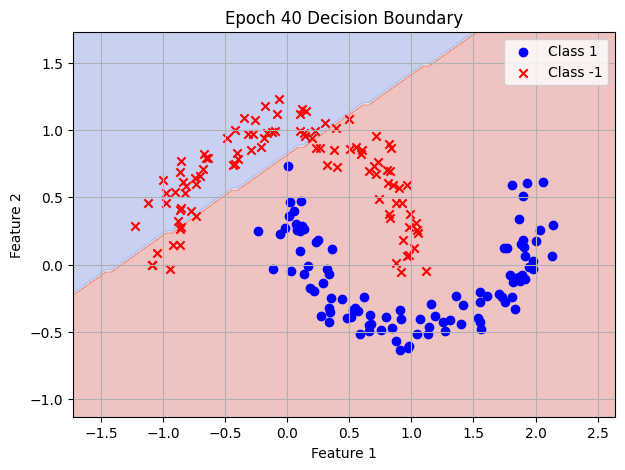

Epoch 41/50, Errors: 39, Weights: [ 0.01051962 -0.02879978], Bias: 0.01
Epoch 42/50, Errors: 36, Weights: [ 0.00823776 -0.02304065], Bias: 0.01
Epoch 43/50, Errors: 38, Weights: [ 0.00107403 -0.01450791], Bias: 0.01
Epoch 44/50, Errors: 46, Weights: [ 0.01043444 -0.02900211], Bias: 0.01
Epoch 45/50, Errors: 36, Weights: [ 0.00815258 -0.02324299], Bias: 0.01
Epoch 46/50, Errors: 38, Weights: [ 0.01329454 -0.03394475], Bias: 0.01
Epoch 47/50, Errors: 36, Weights: [ 0.01105642 -0.03076064], Bias: 0.01
Epoch 48/50, Errors: 36, Weights: [-0.00089818 -0.03278748], Bias: 0.01
Epoch 49/50, Errors: 36, Weights: [ 0.00245054 -0.03260701], Bias: 0.01
Epoch 50/50, Errors: 35, Weights: [ 0.01470125 -0.02460863], Bias: 0.02


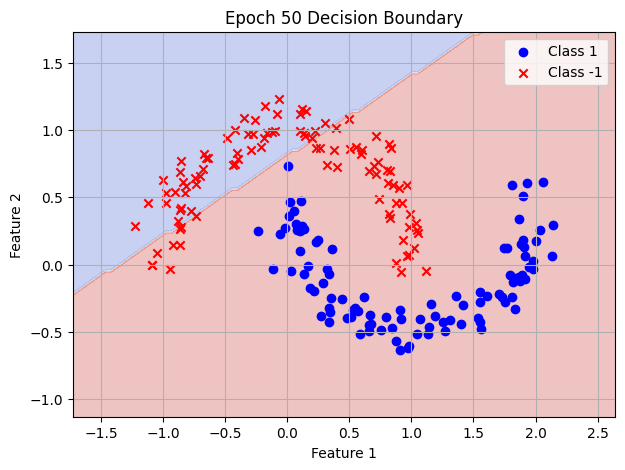

Final weights: [ 0.01470125 -0.02460863], Final bias: 0.02
Final Accuracy on Moons: 75.00%


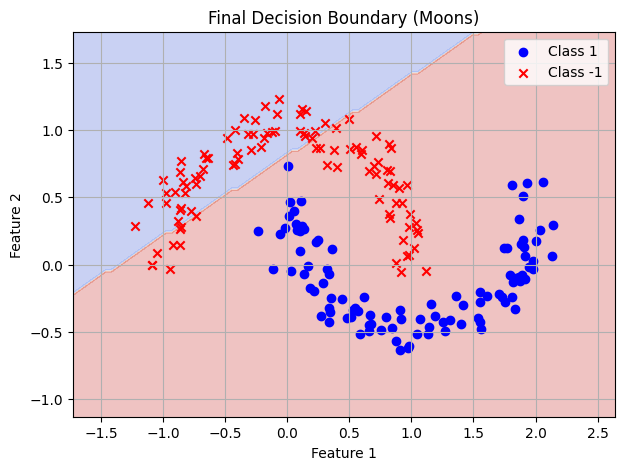

In [ ]:
perceptron_moons = SimplePerceptron(learning_rate=0.01, epochs=50)
# Training with visualization every 10 epochs
perceptron_moons.fit(X_moons, y_moons, plot_during_training=True, plot_interval=10)

# Final Evaluation
final_preds = perceptron_moons.predict(X_moons)
accuracy_moons = np.mean(final_preds == y_moons)
print(f"Final Accuracy on Moons: {accuracy_moons * 100:.2f}%")

plot_perceptron_decision_boundary(X_moons, y_moons, perceptron_moons, title='Final Decision Boundary (Moons)')